# Analisa Data Model Explainability – skforecast

Sumber: https://skforecast.org/0.15.1/user_guides/explainability.html

## Daftar Isi
1. Analisa prediksi tentang apa?
2. Bentuk data training (input & output)
3. Apa itu Lag?
4. Proses analisis
5. Setup
6. Libraries
7. Data
8. Buat dan Latih Forecaster
9. Training Matrix
10. Feature Importance
11. SHAP Values
12. Forecast Explainability
13. Permutation Importance
14. Partial Dependence Plot


## 1. Analisa prediksi tentang apa?

Kasus ini memprediksi total konsumsi listrik harian (Electricity Demand) dalam satuan MWh/hari di Victoria, Australia. Tujuannya bukan hanya menghasilkan prediksi tetapi memahami alasan prediksi melalui explainability.


## 2. Bentuk Data Training

| Kolom | Peran | Keterangan |
|--------|--------|--------|
| lag_1 | INPUT | Demand kemarin |
| lag_2 | INPUT | Demand 2 hari lalu |
| lag_3 | INPUT | Demand 3 hari lalu |
| lag_4 | INPUT | Demand 4 hari lalu |
| lag_5 | INPUT | Demand 5 hari lalu |
| lag_6 | INPUT | Demand 6 hari lalu |
| lag_7 | INPUT | Demand seminggu lalu |
| Temperature | INPUT (exogenous) | Suhu rata-rata |
| Demand | OUTPUT | Target |


## 3. Apa itu Lag?

Lag adalah nilai target pada waktu sebelumnya (t-k). Dengan lag, forecasting diubah menjadi regresi tabular yang dapat dipelajari LightGBM.


## 4. Proses Analisis

- Download dataset vic_electricity
- Agregasi ke harian
- Split train-test
- Train ForecasterRecursive + LightGBM
- Feature Importance
- SHAP Analysis
- Permutation Importance
- PDP


In [25]:
# Install libraries
# ==============================================================================
!pip install skforecast==0.15.1 lightgbm shap

In [26]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

## Data


Dataset yang dipakai: konsumsi listrik Victoria, Australia — data setengah-jam yang di-aggregate ke harian. Kolom Demand adalah total konsumsi (MWh/hari) yang mau diprediksi, dan Temperature adalah suhu rata-rata sebagai variabel tambahan (exogenous).

In [27]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head()

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True
2011-12-31 14:30:00,3877.563330,20.55,2012-01-01,True
2011-12-31 15:00:00,4036.229746,20.40,2012-01-01,True


In [28]:
data = data.resample('D').agg({
    'Demand':'sum',
    'Temperature':'mean'
})
data.head()

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042
2012-01-03,258955.329422,24.567708
2012-01-04,213792.376946,18.191667


In [5]:
data_train = data.loc[:'2014-12-21']
data_test = data.loc['2014-12-22':]

## Buat dan Latih Forecaster

In [6]:
forecaster = ForecasterRecursive(
    regressor=LGBMRegressor(random_state=123, verbose=-1),
    lags=7
)

forecaster.fit(
    y=data_train['Demand'],
    exog=data_train['Temperature']
)

forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Exogenous included: True 
Exogenous names: Temperature 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 09:21:27 
Last fit date: 2026-06-11 09:21:27 
Skforecast version: 0.15.1 
Python version: 3.12.13 
Forecaster id: None

## Feature Importance

In [7]:
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


## Training Matrix

In [8]:
X_train, y_train = forecaster.create_train_X_y(
    y=data_train['Demand'],
    exog=data_train['Temperature']
)

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


## SHAP Values

In [9]:
shap.initjs()
explainer = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

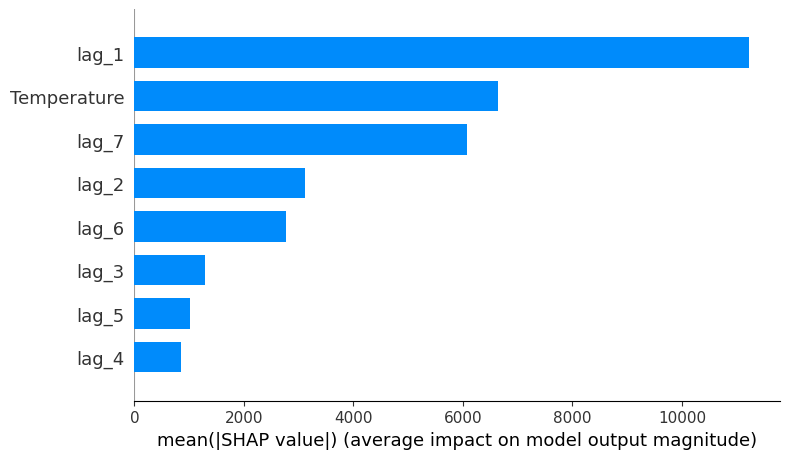

In [10]:
shap.summary_plot(
    shap_values,
    X_train,
    plot_type='bar'
)

**SHAP Summary Plot (Beeswarm)**

Lebih detail dari bar plot — tiap titik adalah satu observasi. Warna merah = nilai fitur tinggi, biru = rendah. Posisi horizontal menunjukkan arah pengaruh: kanan = naikkan prediksi, kiri = turunkan.

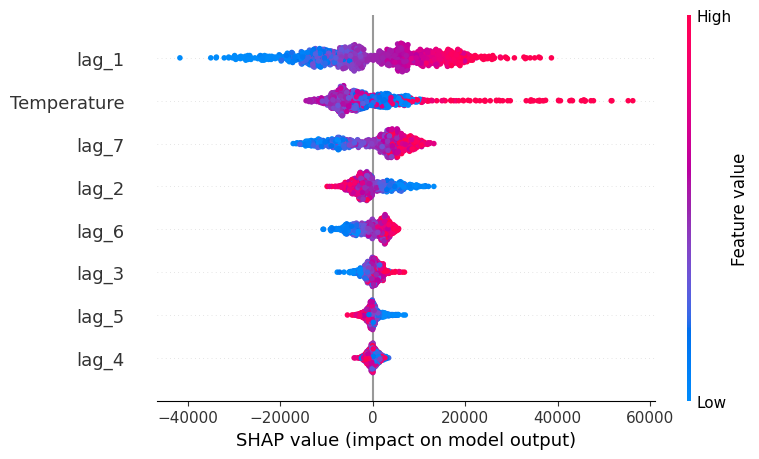

In [11]:
shap.summary_plot(
    shap_values,
    X_train
)

**SHAP Force Plot – Satu Prediksi (Observasi Pertama)**

Force plot menjelaskan satu prediksi spesifik — fitur mana yang mendorong nilai naik (merah) dan mana yang menarik turun (biru) dari nilai baseline model.

In [29]:
# Force plot for the first observation
# ==============================================================================
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

**SHAP Force Plot – 200 Observasi Sekaligus**

Bisa divisualisasikan banyak observasi sekaligus untuk melihat pola kontribusi fitur dari waktu ke waktu.

In [30]:
# Force plot for the first 200 observations in the training set
# ==============================================================================
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[:200, :],
    X_train.iloc[:200, :]
)

**SHAP Dependence Plot**


Menunjukkan hubungan antara nilai suatu fitur dengan nilai SHAP-nya. Bisa terlihat apakah pengaruhnya linear atau non-linear, dan ada interaksi dengan fitur lain (warna titik).

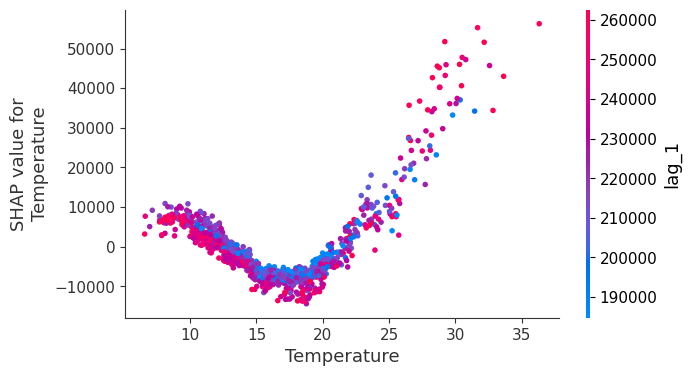

In [14]:
fig, ax = plt.subplots(figsize=(7,4))
shap.dependence_plot(
    'Temperature',
    shap_values,
    X_train,
    ax=ax
)

## Menjelaskan Nilai Forecast


Nilai SHAP juga dapat digunakan untuk menjelaskan hasil prediksi (forecasted values). Hal ini dapat dilakukan dengan memanfaatkan matriks input yang digunakan oleh metode predict pada forecaster.

Dengan kata lain, SHAP menganalisis fitur-fitur yang menjadi masukan ke model saat proses prediksi, sehingga dapat diketahui seberapa besar kontribusi masing-masing fitur terhadap nilai hasil forecast yang dihasilkan oleh model.

In [15]:
predictions = forecaster.predict(
    steps=10,
    exog=data_test['Temperature']
)
predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


In [33]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


In [31]:
# Force plot for a specific prediction
# ==============================================================================
shap.initjs()
predicted_date      = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values         = explainer.shap_values(X_predict)

shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

## Permutation Importance

Cara kerja: satu fitur dikocok acak (nilainya diacak hingga kehilangan hubungan dengan target), lalu diukur seberapa besar performa model turun. Penurunan besar artinya fitur itu sangat penting. Metode ini lebih objektif karena mengukur dampak nyata ke performa, bukan statistik internal model.

In [34]:
# Permutation importances
# ==============================================================================
r = permutation_importance(
    estimator    = forecaster.regressor,
    X            = X_train,
    y            = y_train,
    n_repeats    = 3,
    max_samples  = 0.5,
    random_state = 123
)

importances = pd.DataFrame({
    'feature'         : X_train.columns,
    'mean_importance' : r.importances_mean,
    'std_importance'  : r.importances_std
}).sort_values('mean_importance', ascending=False)

importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


## Partial Dependence Plot (PDP)

PDP menunjukkan rata-rata pengaruh satu fitur terhadap prediksi, sementara fitur lain dianggap konstan (dimarginalisasi). Berguna untuk melihat apakah hubungannya linear, U-shape, atau pola lain. Di sini kita lihat PDP untuk Temperature dan lag_1.

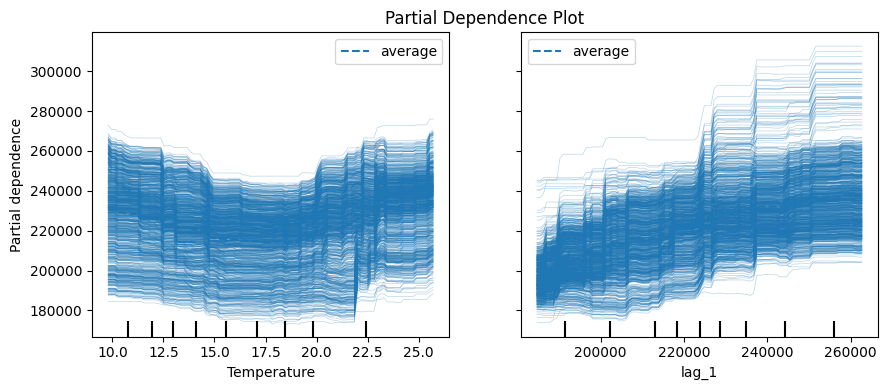

In [35]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.regressor,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout();